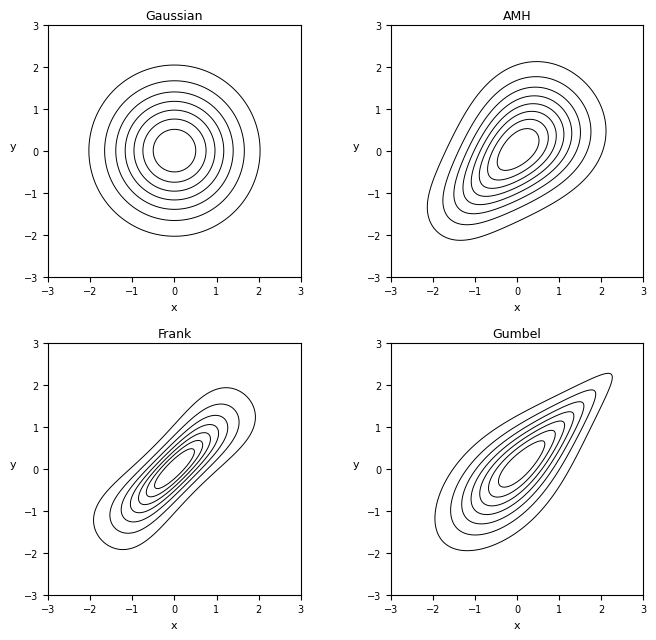

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import ndtri

N   = 300
eps = 1e-10
x   = np.linspace(-3, 3, N)
X1, X2 = np.meshgrid(x, x)

U1 = np.clip(norm.cdf(X1), eps, 1 - eps)
U2 = np.clip(norm.cdf(X2), eps, 1 - eps)
phi1, phi2 = norm.pdf(X1), norm.pdf(X2)

# ── Copula CDFs ──────────────────────────────────────────────────

def gaussian_copula_density(u1, u2, rho):
    z1, z2 = ndtri(u1), ndtri(u2)
    r2 = 1 - rho**2
    return (1/np.sqrt(r2)) * np.exp(
        -(rho**2*(z1**2+z2**2) - 2*rho*z1*z2) / (2*r2))

def amh_C(u1, u2, theta):
    return u1*u2 / (1 - theta*(1-u1)*(1-u2))

def frank_C(u1, u2, theta):
    e = np.exp(-theta)
    return -1/theta * np.log(
        1 + (np.exp(-theta*u1)-1)*(np.exp(-theta*u2)-1)/(e-1))

def gumbel_C(u1, u2, theta):
    A = (-np.log(np.clip(u1,eps,1-eps)))**theta \
      + (-np.log(np.clip(u2,eps,1-eps)))**theta
    return np.exp(-A**(1/theta))

def copula_density_numerical(C_func, u1, u2, **kw):
    h = 1e-4
    c = (C_func(u1+h, u2+h, **kw) - C_func(u1+h, u2-h, **kw)
       - C_func(u1-h, u2+h, **kw) + C_func(u1-h, u2-h, **kw)) / (4*h*h)
    return np.maximum(c, 0)

# ── Joint densities F(x1,x2) = c(Φ(x1),Φ(x2)) · φ(x1) · φ(x2) ──

Z_gauss  = gaussian_copula_density(U1, U2, rho=0.0)              * phi1 * phi2
Z_amh    = copula_density_numerical(amh_C,   U1, U2, theta=0.9)  * phi1 * phi2
Z_frank  = copula_density_numerical(frank_C, U1, U2, theta=8.0)  * phi1 * phi2
Z_gumbel = copula_density_numerical(gumbel_C,U1, U2, theta=2.0)  * phi1 * phi2

# ── 2×2 contour plot ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(7, 7))
configs = [
    (Z_gauss,  r'Gaussian',  axes[0,0]),
    (Z_amh,    r'AMH',   axes[0,1]),
    (Z_frank,  r'Frank',   axes[1,0]),
    (Z_gumbel, r'Gumbel',  axes[1,1]),
]

for Z, title, ax in configs:
    vmax   = np.percentile(Z[np.isfinite(Z)], 99.5)
    Z_plot = np.clip(Z, 0, vmax)
    ax.contour(X1, X2, Z_plot, levels=8, colors='black', linewidths=0.7)
    ax.set_xlim(-3, 3);  ax.set_ylim(-3, 3)
    ax.set_xlabel('x', fontsize=8);  ax.set_ylabel('y', fontsize=8, rotation=0, labelpad=8)
    ax.tick_params(labelsize=7);     ax.set_aspect('equal')
    ax.set_title(title, fontsize=9, pad=4)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig('fig45_copula_contours.png', dpi=200, bbox_inches='tight', transparent=True)
plt.show()